# 📊 Assignment: Predicting 2024 Data Science Salaries Using Linear Regression

**Course**: Data Analytics with Python  
**Instructor**: Leonard Andrew Mesiera  
**Due Date**: October 22, 2025

## 🎯 Learning Objectives
By the end of this assignment, you will be able to:
- Load and explore a real-world dataset
- Prepare data for linear regression (feature engineering, encoding, cleaning)
- Train a simple linear regression model using `scikit-learn`
- Evaluate your model using metrics like R² and interpret results
- Make predictions for future years (e.g., 2024)

## 📁 Dataset
You are given the file: `Data Science Salary 2021 to 2023.csv`

This dataset contains salary information for data professionals from 2021 to 2023, including:
- `work_year`: The year the salary was recorded
- `experience_level`: EN (Entry), MI (Mid), SE (Senior), EX (Executive)
- `job_title`: e.g., Data Scientist, Data Analyst, etc.
- `salary_in_usd`: Salary converted to USD (this is your target variable)
- Other useful columns: `employment_type`, `company_location`, `company_size`

Your goal: **Predict average salaries for 2024** using linear regression.

In [1]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 🛠️ Part 1: Setup and Data Loading

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv('DSS.csv')

# Display first few rows
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,company_location,company_size
0,2023,EN,FT,Applied Scientist,213660,USD,213660,US,L
1,2023,EN,FT,Applied Scientist,130760,USD,130760,US,L
2,2023,EN,FT,Data Quality Analyst,100000,USD,100000,NG,L
3,2023,EN,FT,Compliance Data Analyst,30000,USD,30000,NG,L
4,2023,EN,FT,Applied Scientist,204620,USD,204620,US,L


In [3]:
# Check basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3761 entries, 0 to 3760
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   work_year         3761 non-null   int64 
 1   experience_level  3761 non-null   object
 2   employment_type   3761 non-null   object
 3   job_title         3761 non-null   object
 4   salary            3761 non-null   int64 
 5   salary_currency   3761 non-null   object
 6   salary_in_usd     3761 non-null   int64 
 7   company_location  3761 non-null   object
 8   company_size      3761 non-null   object
dtypes: int64(3), object(6)
memory usage: 264.6+ KB


## 🔍 Part 2: Exploratory Data Analysis (EDA)

Answer the following in markdown cells below (or as code comments):

1. How many unique job titles are there?
2. What is the average salary (`salary_in_usd`) per `work_year`?
3. Create a bar plot showing average salary by `experience_level`.

> 💡 Tip: Use `groupby()` and `mean()`.

<h3>There are 93 Job titles</h3>

In [10]:
unique_jobs = df['job_title'].dropna().astype(str).str.strip().unique()
print("Number of unique job titles:", len(unique_jobs))
print("\nUnique job titles:")
for job in unique_jobs:
    print(job)

Number of unique job titles: 93

Unique job titles:
Applied Scientist
Data Quality Analyst
Compliance Data Analyst
Machine Learning Engineer
Research Scientist
Data Engineer
Data Analyst
Data Scientist
BI Data Engineer
Research Engineer
Business Data Analyst
Autonomous Vehicle Technician
Applied Machine Learning Scientist
AI Programmer
AI Developer
Computer Vision Engineer
BI Developer
Big Data Engineer
Deep Learning Engineer
Head of Data
Analytics Engineer
Data Architect
Director of Data Science
Head of Data Science
Data Analytics Manager
ML Engineer
Applied Machine Learning Engineer
Applied Data Scientist
ETL Engineer
Data Specialist
Lead Data Analyst
Data Manager
Machine Learning Scientist
MLOps Engineer
Financial Data Analyst
Software Data Engineer
Data Science Manager
Data Science Consultant
Machine Learning Infrastructure Engineer
Insight Analyst
AI Scientist
Data Infrastructure Engineer
Data Science Lead
Product Data Analyst
Data Analytics Lead
Machine Learning Research Engineer

<h3>AVERAGE SALARY PER YEAR</h3>

In [11]:
avg_salary_per_year = df.groupby('work_year')['salary_in_usd'].mean().reset_index()

# Display result
print("Average Salary (USD) per Work Year:")
print(avg_salary_per_year)

Average Salary (USD) per Work Year:
   work_year  salary_in_usd
0       2020   92302.631579
1       2021   94087.208696
2       2022  133379.510804
3       2023  148954.558413


<h3>AVERAGE SALARY BY EXPERIENCE</h3>

Average Salary (USD) by Experience Level:
  experience_level  salary_in_usd
0               EN   78546.284375
1               EX  194930.929825
2               MI  104544.864030
3               SE  153062.468626


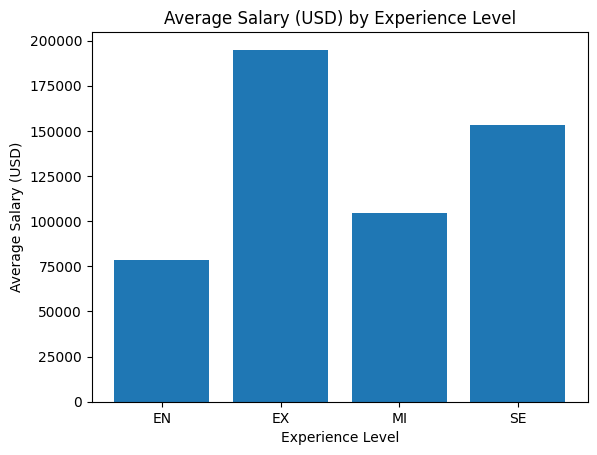

In [12]:
avg_salary_by_exp = df.groupby('experience_level')['salary_in_usd'].mean().reset_index()

# Display the data
print("Average Salary (USD) by Experience Level:")
print(avg_salary_by_exp)

# Create a bar plot
plt.bar(avg_salary_by_exp['experience_level'], avg_salary_by_exp['salary_in_usd'])
plt.title('Average Salary (USD) by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary (USD)')
plt.show()

## 🧹 Part 3: Data Preprocessing for Linear Regression

We will predict `salary_in_usd` using **only numerical or encoded categorical features**.

### Steps:
1. Select features: `work_year`, `experience_level`, and optionally `job_title` (you decide!)
2. Encode categorical variables (`experience_level`) using `LabelEncoder` or `pd.get_dummies()`
3. Define `X` (features) and `y` (target = `salary_in_usd`)

> ⚠️ **Important**: Do NOT include `salary`, `salary_currency`, or `salary_in_usd` in your features!

In [29]:
features = ['work_year', 'experience_level']
le = LabelEncoder()
df['experience_level_encoded'] = le.fit_transform(df['experience_level'])
X = df[['work_year', 'experience_level_encoded']]
y = df['salary_in_usd']

X.head()

,work_year,experience_level_encoded
0,2023,0
1,2023,0
2,2023,0
3,2023,0
4,2023,0


## 📈 Part 4: Train a Linear Regression Model

In [30]:
# Split data into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R² Score: 0.15
RMSE: 59164.82


## 🔮 Part 5: Predict 2024 Salaries

Now, create a small DataFrame for **2024** with different experience levels and predict their salaries.

Use the same encoding as before!

In [31]:
# Map experience levels to encoded values (check your LabelEncoder!)
# Example: EN=0, MI=1, SE=2, EX=3 (confirm with `le.classes_`)

future_data = pd.DataFrame({
    'work_year': [2024, 2024, 2024, 2024],
    'experience_level_encoded': [0, 1, 2, 3]  # EN, MI, SE, EX
})

# Predict
predicted_salaries = model.predict(future_data)

# Display results
results = pd.DataFrame({
    'Experience Level': ['Entry', 'Mid', 'Senior', 'Executive'],
    'Predicted 2024 Salary (USD)': predicted_salaries
})
results

,Experience Level,Predicted 2024 Salary (USD)
0,Entry,111694.914909
1,Mid,131967.434578
2,Senior,152239.954247
3,Executive,172512.473916


## 📝 Part 6: Reflection (Answer in a Markdown Cell)

1. Does your model make reasonable predictions? Why or why not?
2. What are the limitations of using only `work_year` and `experience_level`?
3. How could you improve this model? (Think: more features, better encoding, etc.)
4. Why is **R² not enough** to trust your predictions?

> 💡 Remember: Linear regression assumes a **linear trend**—but real salaries may grow non-linearly!

<h3>1. No, the model doesn’t make very good predictions because it uses only a few features. It can’t capture all the things that affect a person’s salary.</h3>

<h3>2. It misses other important factors like job title and location. Because of that, the model becomes too simple and not very accurate.</h3>

<h3>3. I can add more features like job title, company size, and location. This will help the model learn more and predict better.</h3>

<h3>4. R² only shows how good the model fits the data. It doesn’t show if the predictions are really right or wrong.</h3>

## 📤 Submission Instructions

- Save this notebook as: `LastName_FirstName_SalaryPrediction.ipynb`
- Ensure all code runs without errors
- Include your answers to the reflection questions
- Submit via [your LMS/email/etc.]

Good luck! 🚀